In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.common import extract_latents
from run_models import run_VAE, run_KMeans, run_Agglomerative, run_DBSCAN
from config import config

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np
from pathlib import Path

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

In [6]:
conv_vae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="conv", root=root, plot_dir_name="medium_1_conv_vae_audio_only")

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-10 08:46:07,237] A new study created in memory with name: Convolutional VAE Tuning
  0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 275.5166     | 273.6012    
Recon        | 270.5074     | 271.7572    
KL Div       | 25.0462      | 9.2199      
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 239.2249     | 233.3002    
Recon        | 233.3917     | 228.1126    
KL Div       | 29.1660      | 25.9380     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 222.3030     | 215.1004    
Recon        | 216.5728     | 209.3044    
KL Div       | 28.6511      | 28.9797     
--------------------------------------

  0%|          | 0/5 [00:04<?, ?it/s]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 202.6053     | 198.9580    
Recon        | 197.0835     | 193.2904    
KL Div       | 27.6092      | 28.3379     
--------------------------------------------------

[I 2026-04-10 08:46:12,062] Trial 0 finished with value: 127.30941899565076 and parameters: {'CHANNEL_1': 4, 'CHANNEL_2_MULTIPLIER': 8, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 16, 'LR': 0.0001519934830130982, 'BATCH_SIZE': 64, 'BETA': 3.0}. Best is trial 0 with value: 127.30941899565076.


Best trial: 0. Best value: 127.309:  20%|██        | 1/5 [00:05<00:20,  5.01s/it]

...

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 245.7900     | 171.8065    
Recon        | 237.5277     | 164.7971    
KL Div       | 41.3116      | 35.0468     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 128.5744     | 94.9725     
Recon        | 122.0251     | 88.3276     
KL Div       | 32.7466      | 33.2245     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 85.2211      | 70.6203     
Recon        | 78.2171      | 62.4657     
KL Div       | 35.0200      | 40.7729     
--------------------------------------

Best trial: 2. Best value: 55.8063:  80%|████████  | 4/5 [00:39<00:07,  7.91s/it]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 63.0284      | 57.8462     
Recon        | 55.4824      | 49.9791     
KL Div       | 37.7299      | 39.3358     
--------------------------------------------------

[I 2026-04-10 08:46:47,152] Trial 4 finished with value: 45.72174162874517 and parameters: {'CHANNEL_1': 8, 'CHANNEL_2_MULTIPLIER': 2, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 32, 'LR': 0.0002572663133249957, 'BATCH_SIZE': 16, 'BETA': 3.0}. Best is trial 4 with value: 45.72174162874517.


Best trial: 4. Best value: 45.7217: 100%|██████████| 5/5 [00:40<00:00,  8.02s/it]


..\..\results\trials\medium_1_conv_vae_audio_only\plots
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\optimization_history.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\param_importances.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\parallel_coordinate.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\edf.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\timeline.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\contour.html
Best trial for `conv`:
Score: 45.7217
    CHANNEL_1                 8
    CHANNEL_2_MULTIPLIER      2
    CHANNEL_3_MULTIPLIER      4
    LATENT_DIM                32
    LR                        0.0002572663133249957
    BATCH_SIZE                16
    BETA                      3.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(8, eps

In [7]:
train_latents, _ = extract_latents(model=conv_vae, loader=train_loader, device=device)
test_latents,  _  = extract_latents(model=conv_vae, loader=test_loader,  device=device)

In [8]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)




Optimal k        : 5
Inertia (WCSS)   : 32902.5195
Silhouette Score : 0.1799
CH Index         : 468.2537
DB Index         : 1.7395



n_clusters not provided for Agglomerative — running elbow method to determine k...



Agglomerative  n_clusters=5  linkage='ward'
Silhouette Score : 0.1543
CH Index         : 399.9206
DB Index         : 1.9588






DBSCAN  eps=2.5  min_samples=5
Clusters found   : 7
Noise points     : 1031



DB-SCAN
Silhouette Score : 0.0156
CH Index         : 137.6856
DB Index         : 1.5459





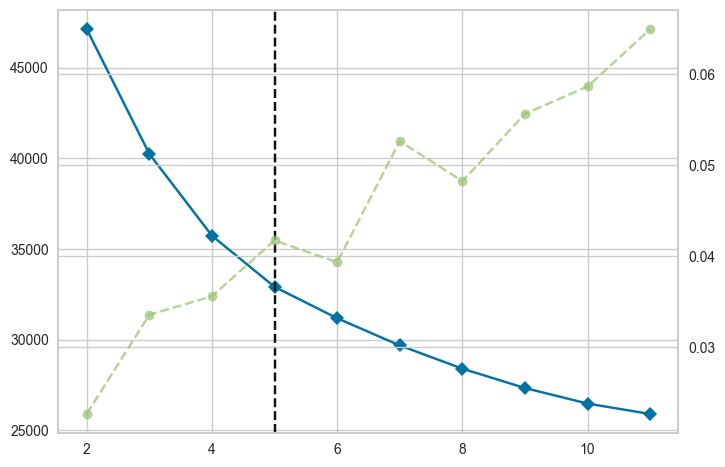

In [9]:
vae_kmeans, vae_kmeans_metrics = run_KMeans(vae_latents, model_type="medium_1_conv_vae_audio_only", root=root)
vae_agglomerative, vae_agglomerative_metrics = run_Agglomerative(vae_latents, model_type="medium_1_conv_vae_audio_only", root=root)
vae_dbscan, vae_dbscan_metrics = run_DBSCAN(vae_latents, model_type="medium_1_conv_vae_audio_only", root=root)

In [10]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [11]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\medium_1_conv_vae_audio_only


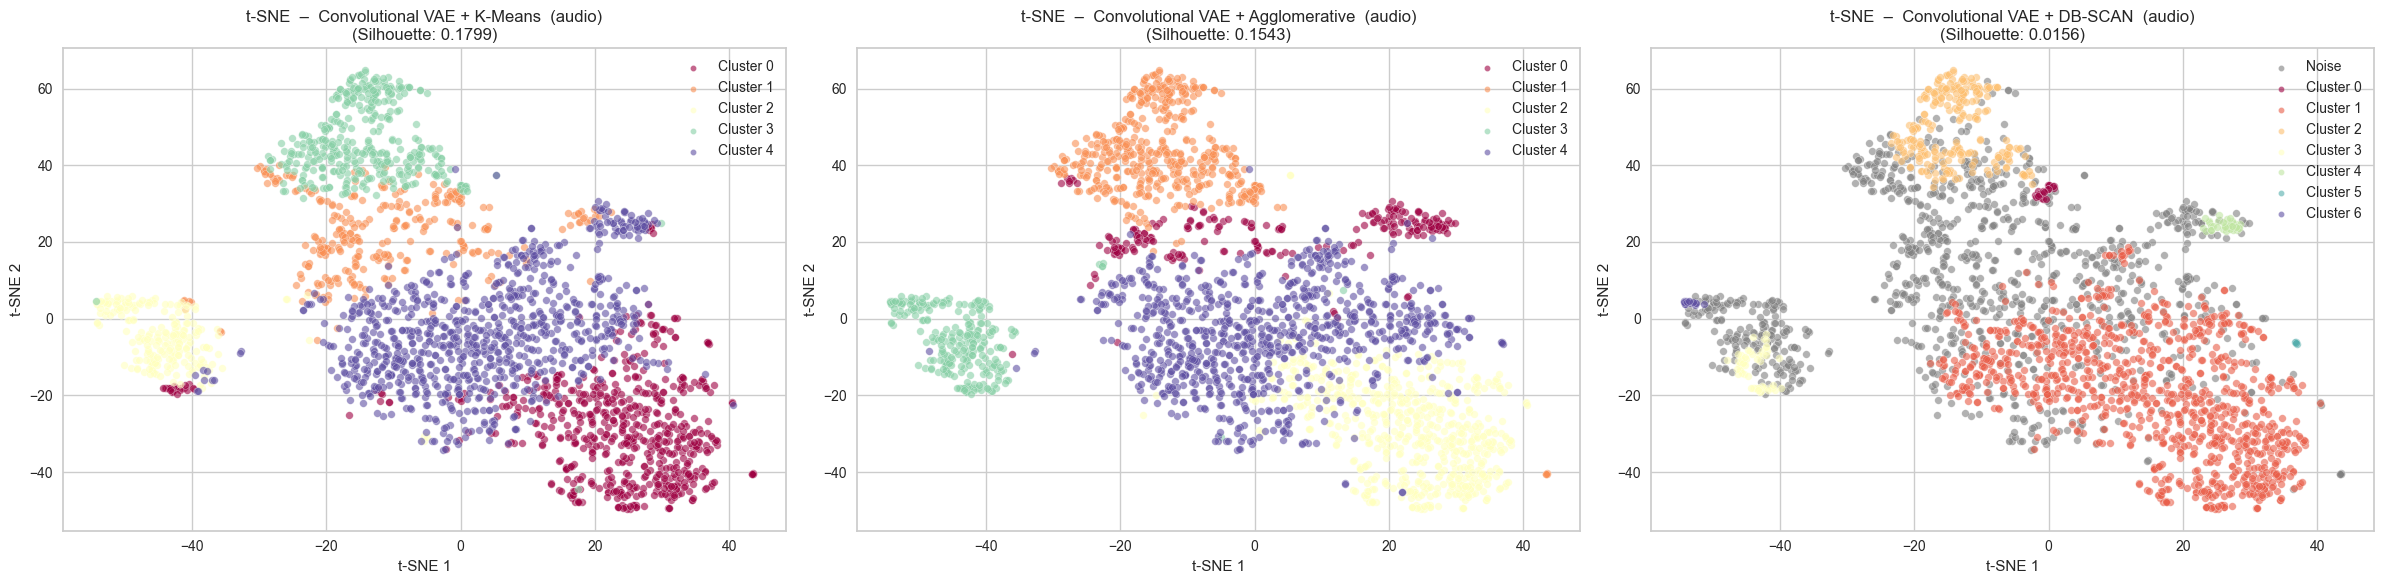

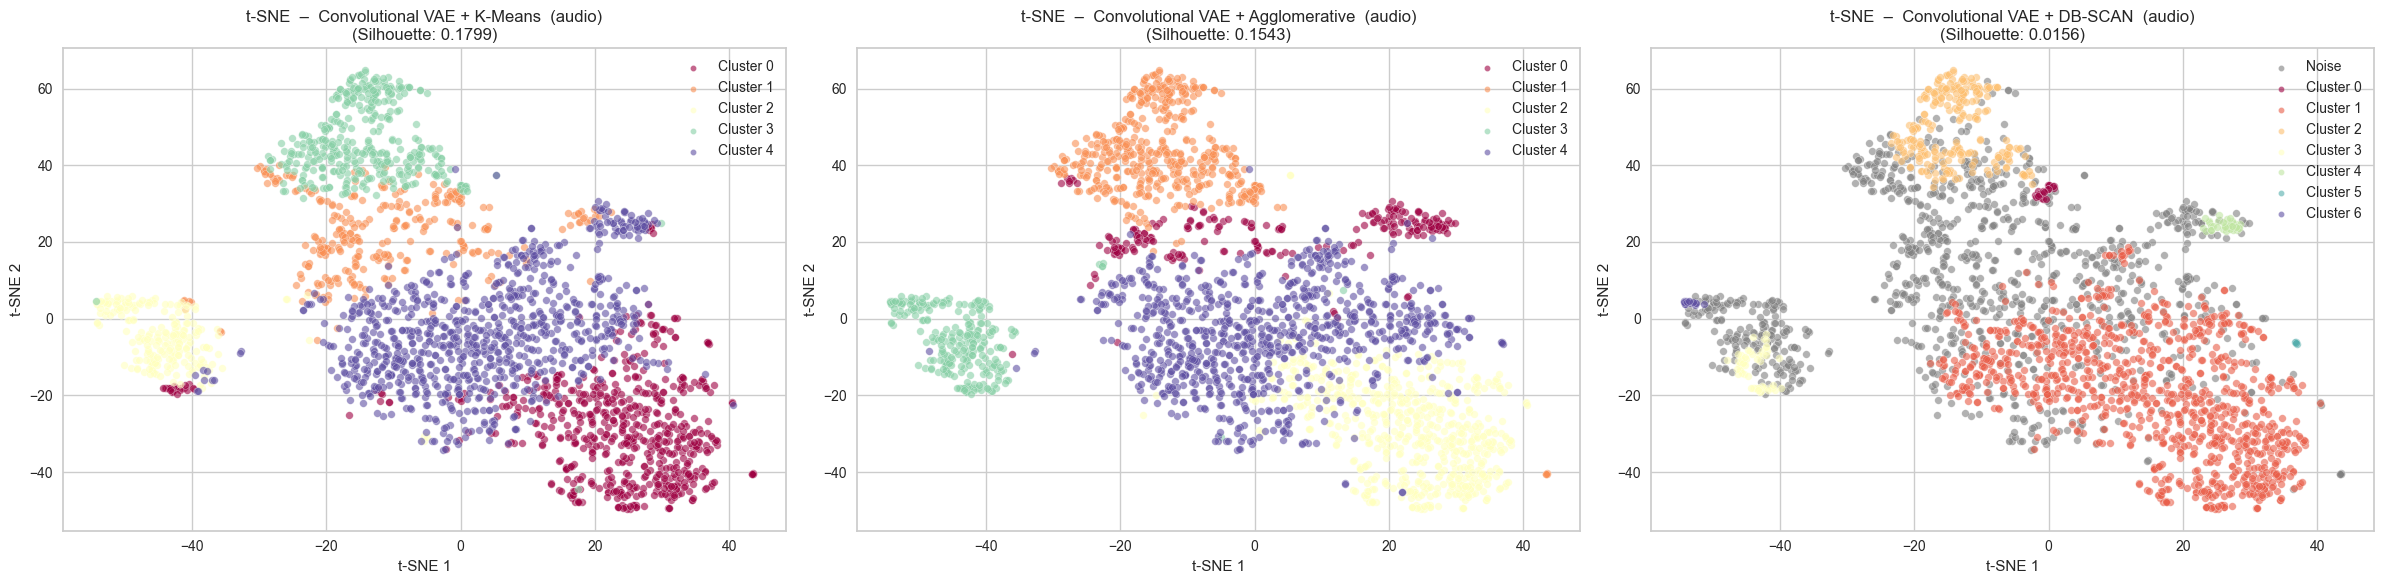

In [12]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, vae_agglomerative.labels_, vae_dbscan.labels_],
    ["Convolutional VAE + K-Means  (audio)", "Convolutional VAE + Agglomerative  (audio)", "Convolutional VAE + DB-SCAN  (audio)"],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_), silhouette_score(vae_latents, vae_agglomerative.labels_), silhouette_score(vae_latents, vae_dbscan.labels_)], # type: ignore
    save_path=TSNE_DIR / "medium_1_conv_vae_audio_only"
)